<a href="https://colab.research.google.com/github/olaoluwaolu/ML-Biomed/blob/main/Audio_DT_RF_MiniSpeechCommands.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🎙️ Audio ML in Scikit‑Learn: Decision Trees & Random Forests on Mini Speech Commands

** This Tutorial is only for EE502 Class Demonstrattion. This is by no menas a production ready example. AI help was sought to develop this tutorial**

- How to **download** an open‑access audio dataset (Mini Speech Commands)  
- How to **extract audio features** (MFCCs, spectral stats) with `librosa`  
- How to **train and validate** Decision Tree (DT) and Random Forest (RF) models  
- How to run **k‑fold cross‑validation** and **GridSearchCV**  
- How to do **performance analysis**: accuracy, confusion matrix, ROC, learning curves  
- How to **interpret** RF feature importances and **visualize** a small Decision Tree  

> **Run time tip:** This notebook uses a **small** dataset and caps files per class for quick class demos.  
> You can raise `MAX_FILES_PER_LABEL` later to improve model performance at the cost of more runtime.


In [ ]:

#@title 🔧 Setup: Install and import dependencies (run once)
# This cell installs required libraries in Colab and imports everything needed.
# If you're running in Google Colab, the `!pip` commands will work as-is.
# On other environments, you can comment them out if already installed.

!pip -q install librosa soundfile tqdm

import os
import glob
import math
import random
import zipfile
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display
import soundfile as sf

from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder, LabelBinarizer
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, GridSearchCV, learning_curve, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, RocCurveDisplay, accuracy_score,
                             mean_squared_error, mean_absolute_error, r2_score)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Make plots a bit larger for classroom viewing
plt.rcParams['figure.figsize'] = (8, 6)


In [ ]:

#@title ⬇️ Download the Mini Speech Commands dataset
# This dataset is the "mini" version used in TensorFlow tutorials—small and perfect for class demos.
# Source (TensorFlow tutorial): http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip

DATASET_URL = "http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip"
DATA_DIR = pathlib.Path("mini_speech_commands")
ZIP_PATH = "mini_speech_commands.zip"

if not DATA_DIR.exists():
    # Download the zip
    if not os.path.exists(ZIP_PATH):
        print("Downloading dataset...")
        import urllib.request
        urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)
    else:
        print("Zip already exists, skipping download.")
    # Extract
    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(".")
else:
    print("Dataset folder already exists, skipping download and extract.")

# Inspect labels available
labels = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir() and not p.name.startswith("_")])
print("Found labels:", labels)


Extracting...
Found labels: ['down', 'go', 'left', 'no', 'right', 'stop', 'up', 'yes']


In [ ]:

#@title ⚙️ Parameters (adjust for class runtime if needed)
# Select which labels to use and cap how many files per label to speed up training.
# The mini dataset typically contains these ten labels:
# ['down','go','left','no','off','on','right','stop','up','yes']

SELECTED_LABELS = ['down','go','left','no','off','on','right','stop','up','yes']  #@param
MAX_FILES_PER_LABEL = 150  #@param {type:"slider", min:50, max:500, step:50}
SAMPLE_RATE = 16000  # all files are 16 kHz in this dataset
DURATION_SEC = 1.0   # ~1 second per clip

# Sanity check and gather files
files_by_label = {}
for lab in SELECTED_LABELS:
    pattern = str(DATA_DIR / lab / "*.wav")
    files = sorted(glob.glob(pattern))
    if MAX_FILES_PER_LABEL is not None:
        files = files[:MAX_FILES_PER_LABEL]
    files_by_label[lab] = files
    print(f"{lab:>5}: {len(files)} files")

total_files = sum(len(v) for v in files_by_label.values())
print(f"Total files selected: {total_files}")


 down: 150 files
   go: 150 files
 left: 150 files
   no: 150 files
  off: 0 files
   on: 0 files
right: 150 files
 stop: 150 files
   up: 150 files
  yes: 150 files
Total files selected: 1200


Example label: go
Example file: mini_speech_commands/go/016e2c6d_nohash_0.wav


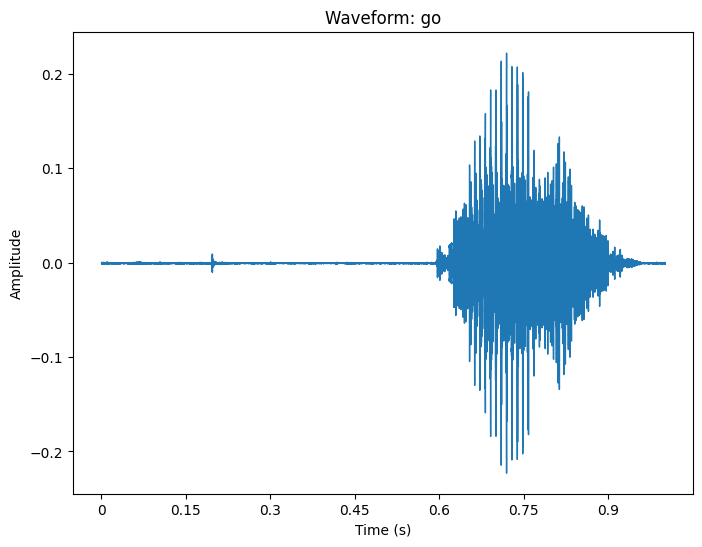

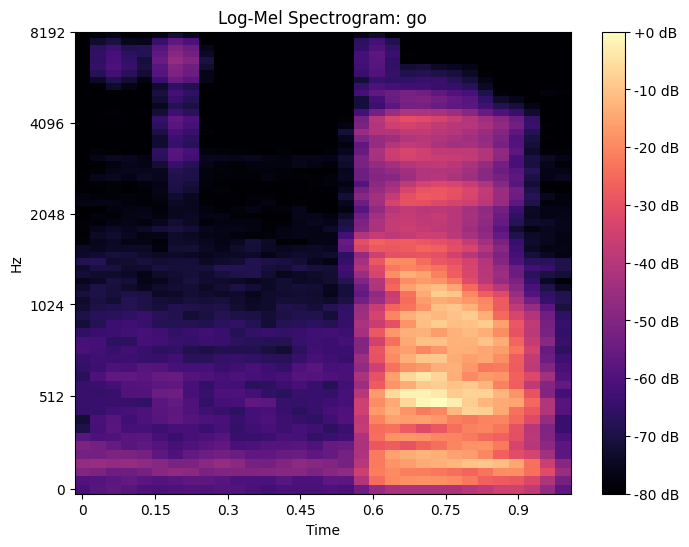

In [ ]:

#@title 👀 Visualize one example: waveform + mel‑spectrogram
# We'll pick a random example and show both waveform and log‑Mel spectrogram.
example_label = random.choice(SELECTED_LABELS)
example_file = random.choice(files_by_label[example_label])
print("Example label:", example_label)
print("Example file:", example_file)

y, sr = librosa.load(example_file, sr=SAMPLE_RATE)  # force 16k
plt.figure()
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform: {example_label}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, fmax=sr/2)
S_db = librosa.power_to_db(S, ref=np.max)
plt.figure()
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel')
plt.title(f"Log-Mel Spectrogram: {example_label}")
plt.colorbar(format="%+2.0f dB")
plt.show()


In [ ]:

#@title 🎛️ Feature extraction helpers
# We'll extract a compact set of features per clip to feed classic ML models:
# - MFCCs (mean/std)
# - MFCC deltas (mean/std)
# - Spectral centroid, bandwidth, rolloff (mean/std)
# - Chromagram (mean/std)
# - Zero-crossing rate (mean/std)
# - RMS energy (mean/std)
#
# The function returns a 1D numpy array of features and a list of feature names
# for interpretability.

def extract_features(y, sr, n_mfcc=40):
    feats = []
    names = []

    # Ensure consistent length (~1s). Pad or trim if needed.
    target_len = int(DURATION_SEC * sr)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    # MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = mfcc.mean(axis=1)
    mfcc_std = mfcc.std(axis=1)
    for i in range(n_mfcc):
        feats.append(mfcc_mean[i])
        names.append(f"mfcc_{i+1}_mean")
    for i in range(n_mfcc):
        feats.append(mfcc_std[i])
        names.append(f"mfcc_{i+1}_std")

    # Delta MFCCs
    mfcc_delta = librosa.feature.delta(mfcc)
    d_mean = mfcc_delta.mean(axis=1)
    d_std = mfcc_delta.std(axis=1)
    for i in range(n_mfcc):
        feats.append(d_mean[i]); names.append(f"mfcc_delta_{i+1}_mean")
    for i in range(n_mfcc):
        feats.append(d_std[i]); names.append(f"mfcc_delta_{i+1}_std")

    # Spectral features
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y=y)
    rms = librosa.feature.rms(y=y)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=12)

    def add_stats(feat, base):
        feats.append(feat.mean()); names.append(f"{base}_mean")
        feats.append(feat.std());  names.append(f"{base}_std")

    add_stats(centroid, "spec_centroid")
    add_stats(bandwidth, "spec_bandwidth")
    add_stats(rolloff, "spec_rolloff")
    add_stats(zcr, "zcr")
    add_stats(rms, "rms")

    # Chroma stats
    chroma_mean = chroma.mean(axis=1)
    chroma_std = chroma.std(axis=1)
    for i in range(chroma.shape[0]):
        feats.append(chroma_mean[i]); names.append(f"chroma_{i+1}_mean")
    for i in range(chroma.shape[0]):
        feats.append(chroma_std[i]);  names.append(f"chroma_{i+1}_std")

    return np.array(feats, dtype=np.float32), names


In [ ]:

#@title 🧱 Build feature matrix X and label vector y
# We'll iterate over files and compute features for each.
# To speed up reruns in Colab, we cache to a .npz file.

CACHE_PATH = "features_mini_speech_commands.npz"
X_list, y_list = [], []
feature_names = None

if os.path.exists(CACHE_PATH):
    print("Loading cached features from", CACHE_PATH)
    data = np.load(CACHE_PATH, allow_pickle=True)
    X = data["X"]
    y = data["y"]
    feature_names = data["feature_names"].tolist()
else:
    print("Extracting features (this may take a couple of minutes)...")
    for lab, files in files_by_label.items():
        for f in tqdm(files, desc=f"Processing {lab}"):
            try:
                y_wav, sr = librosa.load(f, sr=SAMPLE_RATE)
                feats, names = extract_features(y_wav, sr)
                X_list.append(feats)
                y_list.append(lab)
                if feature_names is None:
                    feature_names = names
            except Exception as e:
                # If a file is corrupted, skip it
                print(f"Skipping {f}: {e}")

    X = np.vstack(X_list).astype(np.float32)
    y = np.array(y_list)
    np.savez(CACHE_PATH, X=X, y=y, feature_names=np.array(feature_names, dtype=object))

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features:", len(feature_names))


Extracting features (this may take a couple of minutes)...


Processing down:  11%|█         | 16/150 [00:00<00:02, 51.12it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
Processing no: 100%|██████████| 150/150 [00:02<00:00, 56.81it/s]
Processing off: 0it [00:00, ?it/s]
Processing on: 0it [00:00, ?it/s]
Processing yes: 100%|██████████| 150/150 [00:02<00:00, 56.86it/s]

X shape: (1200, 194)
y shape: (1200,)
Number of features: 194


In [ ]:

#@title ✂️ Train/Validation/Test split
# We create a hold‑out test set and use k‑fold CV on the training split for tuning.

le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
print("Classes:", class_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=SEED, stratify=y_enc
)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

# We'll use stratified k-fold for balanced evaluation across classes
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


Classes: [np.str_('down'), np.str_('go'), np.str_('left'), np.str_('no'), np.str_('right'), np.str_('stop'), np.str_('up'), np.str_('yes')]
Train size: 960  Test size: 240


In [ ]:

#@title 🔁 Baseline 5‑fold CV (no tuning): Decision Tree vs Random Forest
dt_base = DecisionTreeClassifier(random_state=SEED, class_weight="balanced")
rf_base = RandomForestClassifier(random_state=SEED, n_estimators=200, n_jobs=-1, class_weight="balanced_subsample")

dt_scores = cross_val_score(dt_base, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
rf_scores = cross_val_score(rf_base, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)

print(f"Decision Tree CV Accuracy: {dt_scores.mean():.3f} ± {dt_scores.std():.3f}")
print(f"Random Forest CV Accuracy: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")


Decision Tree CV Accuracy: 0.332 ± 0.034
Random Forest CV Accuracy: 0.504 ± 0.041


In [ ]:

#@title 🔎 GridSearchCV: Decision Tree hyperparameters
param_grid_dt = {
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy", "log_loss"]
}

dt_clf = DecisionTreeClassifier(random_state=SEED)
gs_dt = GridSearchCV(dt_clf, param_grid_dt, cv=cv, scoring="accuracy",
                     n_jobs=-1, verbose=1, refit=True)
gs_dt.fit(X_train, y_train)

print("Best DT params:", gs_dt.best_params_)
print("Best DT CV accuracy:", gs_dt.best_score_)

# Show top results as a DataFrame (sorted by mean test score)
dt_results = pd.DataFrame(gs_dt.cv_results_).sort_values("mean_test_score", ascending=False)
dt_results_display = dt_results[["params","mean_test_score","std_test_score","rank_test_score"]].head(10)
dt_results_display


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best DT params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best DT CV accuracy: 0.35208333333333336


,params,mean_test_score,std_test_score,rank_test_score
6,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.352083,0.021999,1
7,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.352083,0.021999,1
25,"{'criterion': 'gini', 'max_depth': 20, 'min_sa...",0.352083,0.021999,1
24,"{'criterion': 'gini', 'max_depth': 20, 'min_sa...",0.352083,0.021999,1
34,"{'criterion': 'gini', 'max_depth': 30, 'min_sa...",0.352083,0.021999,1
33,"{'criterion': 'gini', 'max_depth': 30, 'min_sa...",0.352083,0.021999,1
17,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",0.345833,0.017616,7
35,"{'criterion': 'gini', 'max_depth': 30, 'min_sa...",0.343750,0.034548,8
8,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.343750,0.034548,8
26,"{'criterion': 'gini', 'max_depth': 20, 'min_sa...",0.343750,0.034548,8


In [ ]:

#@title 🔎 GridSearchCV: Random Forest hyperparameters
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 25],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", None]
}

rf_clf = RandomForestClassifier(random_state=SEED, n_jobs=-1)
gs_rf = GridSearchCV(rf_clf, param_grid_rf, cv=cv, scoring="accuracy",
                     n_jobs=-1, verbose=1, refit=True)
gs_rf.fit(X_train, y_train)

print("Best RF params:", gs_rf.best_params_)
print("Best RF CV accuracy:", gs_rf.best_score_)

# Show top results
rf_results = pd.DataFrame(gs_rf.cv_results_).sort_values("mean_test_score", ascending=False)
rf_results_display = rf_results[["params","mean_test_score","std_test_score","rank_test_score"]].head(10)
rf_results_display


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best RF params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Best RF CV accuracy: 0.5052083333333334


,params,mean_test_score,std_test_score,rank_test_score
3,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.505208,0.035325,1
11,"{'max_depth': 25, 'max_features': 'sqrt', 'min...",0.505208,0.035325,1
8,"{'max_depth': 25, 'max_features': 'sqrt', 'min...",0.496875,0.030831,3
0,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.496875,0.030831,3
1,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.495833,0.030441,5
9,"{'max_depth': 25, 'max_features': 'sqrt', 'min...",0.495833,0.030441,5
15,"{'max_depth': 25, 'max_features': None, 'min_s...",0.493750,0.034296,7
7,"{'max_depth': None, 'max_features': None, 'min...",0.493750,0.034296,7
12,"{'max_depth': 25, 'max_features': None, 'min_s...",0.491667,0.037788,9
4,"{'max_depth': None, 'max_features': None, 'min...",0.491667,0.037788,9


In [ ]:

#@title ✅ Final evaluation on the held‑out test set
best_dt = gs_dt.best_estimator_
best_rf = gs_rf.best_estimator_

for name, model in [("Decision Tree", best_dt), ("Random Forest", best_rf)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} — Test Accuracy: {acc:.3f}")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=3))



Decision Tree — Test Accuracy: 0.400
              precision    recall  f1-score   support

        down      0.325     0.433     0.371        30
          go      0.231     0.300     0.261        30
        left      0.393     0.367     0.379        30
          no      0.179     0.167     0.172        30
       right      0.310     0.300     0.305        30
        stop      0.556     0.500     0.526        30
          up      0.600     0.400     0.480        30
         yes      0.759     0.733     0.746        30

    accuracy                          0.400       240
   macro avg      0.419     0.400     0.405       240
weighted avg      0.419     0.400     0.405       240


Random Forest — Test Accuracy: 0.579
              precision    recall  f1-score   support

        down      0.643     0.600     0.621        30
          go      0.480     0.400     0.436        30
        left      0.652     0.500     0.566        30
          no      0.367     0.367     0.367        30
  

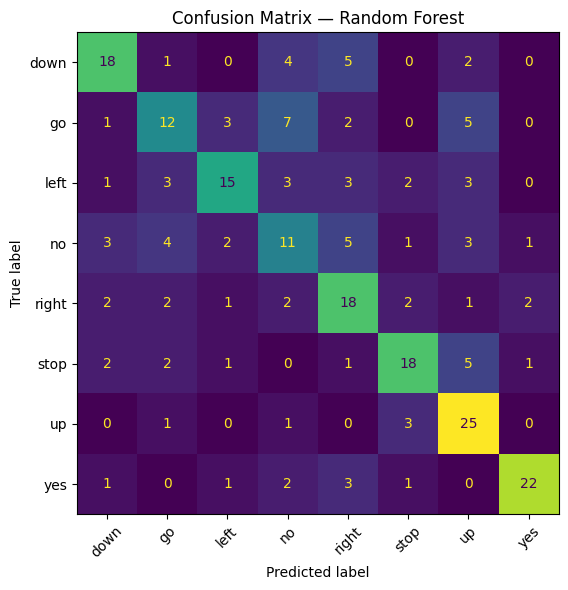

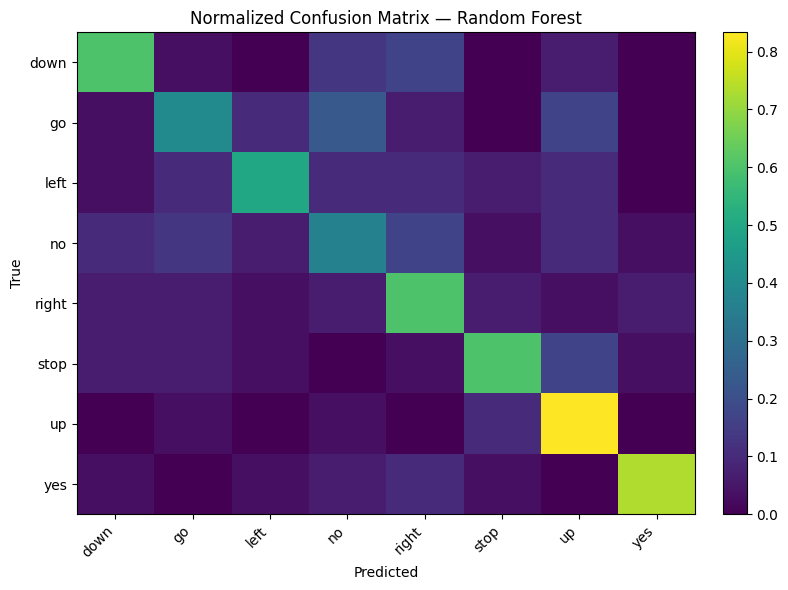

In [ ]:

#@title 🧩 Confusion matrix (Random Forest)
y_pred_rf = best_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

# Plot confusion matrix (standard counts)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots()
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()

# Also show normalized CM for easier reading
cm_norm = confusion_matrix(y_test, y_pred_rf, normalize="true")
fig, ax = plt.subplots()
im = ax.imshow(cm_norm, aspect="auto")
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.title("Normalized Confusion Matrix — Random Forest")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


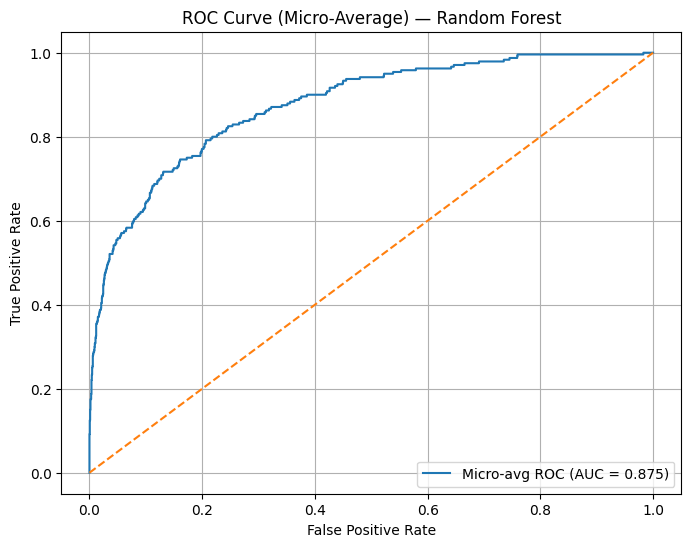

In [ ]:

#@title 📈 ROC curve (micro‑average) — Random Forest
# For multi‑class ROC, we use One-vs-Rest binarization.
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
if y_test_bin.shape[1] == 1:
    # If only two classes, LabelBinarizer returns a single column; make it 2‑col
    y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])

y_score = best_rf.predict_proba(X_test)
# If number of classes differs, align columns (shouldn't happen if trained consistently)
if y_score.shape[1] != y_test_bin.shape[1]:
    # pad or trim (defensive coding)
    min_c = min(y_score.shape[1], y_test_bin.shape[1])
    y_score = y_score[:, :min_c]
    y_test_bin = y_test_bin[:, :min_c]

# Compute micro‑average ROC
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"Micro‑avg ROC (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Micro‑Average) — Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


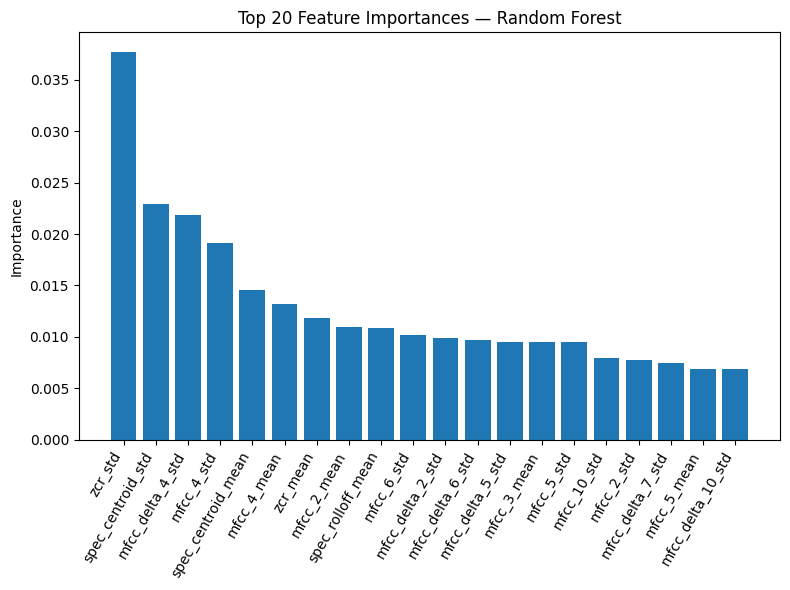

In [ ]:

#@title 🌳 Feature importances — Random Forest (Top 20)
importances = best_rf.feature_importances_
idx_sorted = np.argsort(importances)[::-1][:20]
top_names = [feature_names[i] for i in idx_sorted]
top_vals = importances[idx_sorted]

plt.figure()
plt.bar(range(len(top_vals)), top_vals)
plt.xticks(range(len(top_vals)), top_names, rotation=60, ha="right")
plt.title("Top 20 Feature Importances — Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


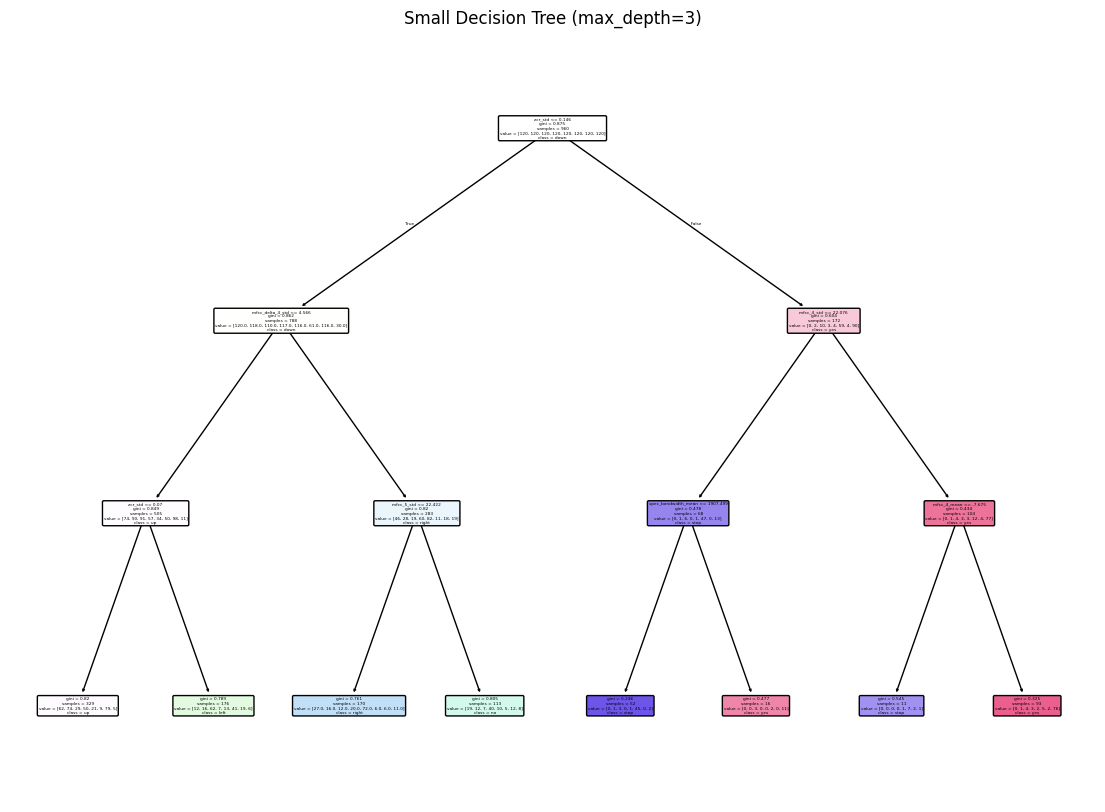

In [ ]:

#@title 🌲 Visualize a small Decision Tree (depth=3)
# For interpretability in class, we'll fit a shallow tree and plot it.
small_tree = DecisionTreeClassifier(max_depth=3, random_state=SEED)
small_tree.fit(X_train, y_train)

plt.figure(figsize=(14, 10))
plot_tree(small_tree, feature_names=feature_names, class_names=class_names, filled=True, rounded=True)
plt.title("Small Decision Tree (max_depth=3)")
plt.show()


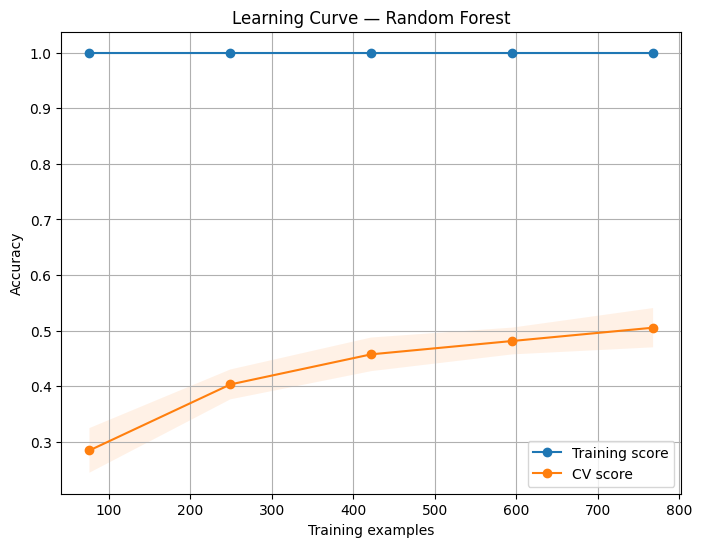

In [ ]:

#@title 📊 Learning curve — Random Forest
train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_train, y_train, cv=cv, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5), scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker="o", label="Training score")
plt.plot(train_sizes, val_mean, marker="o", label="CV score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)
plt.xlabel("Training examples")
plt.ylabel("Accuracy")
plt.title("Learning Curve — Random Forest")
plt.grid(True)
plt.legend()
plt.show()



## ✅ Self-Study:
- Increase `MAX_FILES_PER_LABEL` to improve accuracy.  
- Try different features (e.g., log‑mel means, deltas, tempo).  

